# Basic count program
* Made by Vivian Tao
* Last update by Vivian Tao (June 17, 2025)

This file counts the number of living and dead bacteria based on the diagonal size of the trajectory.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
import pims
import trackpy as tp
from scipy.optimize import curve_fit

In [40]:
@pims.pipeline
def gray(image):
    return image[:, :, 1]

# for files with RGB
#frames = gray(pims.open("data/day6_mar3/*.tif*"))

# change filename here for other files
frames = pims.open("../../analysis/adj_1000ppmCMC_NoField1/*.tif*")

### MICRONS PER PIXEL (upp) REFERENCE:
** for 1024x768 pixels **

In [41]:
UPP_4X = 10/5.567
UPP_10X = 10/13.9735
UPP_20X = 10/28.068
UPP_40X = 10/54.504

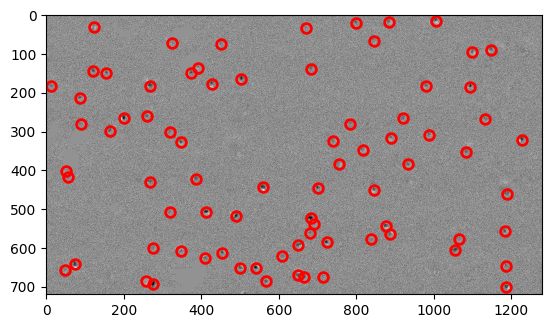

78


<Figure size 640x480 with 0 Axes>

In [42]:
BACT_SIZE = 13 # must be an odd integer, better to be on the larger end
MIN_MASS = 100000
sub_drift = True

upp = UPP_40X # upp is microns per pixel
fps = 10 # fps is frames per second

# prints first frame with annotations - use this to check if BACT_SIZE and MIN_MASS are appropriate for this video and adjust as necessary
for i in [0]: # or use [::50] for every 50th frame
    f = tp.locate(frames[i], BACT_SIZE, invert=True, minmass=MIN_MASS)
    plt.imshow(frames[i])
    tp.annotate(f, frames[i], plot_style={'markersize': 7})
    plt.clf()

print(len(f))


In [43]:
# finds all bacteria in all frames
f = tp.batch(frames[:], BACT_SIZE, invert=True, minmass=MIN_MASS)
tp.quiet(suppress=False)

Frame 475: 83 features


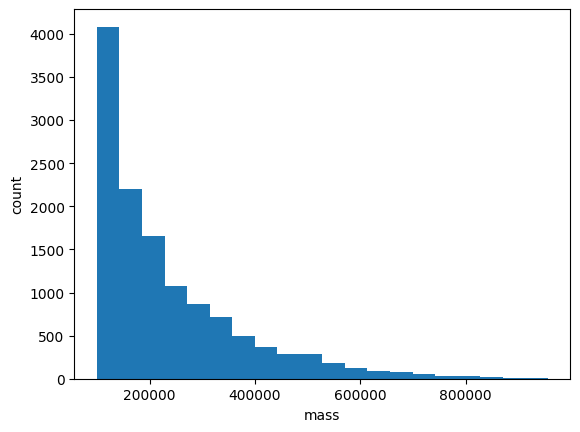

<Figure size 640x480 with 0 Axes>

In [5]:
# plots the mass distribution of all bacteria
fig, ax = plt.subplots()
ax.hist(f['mass'], bins=20)
# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count')
plt.show()
plt.clf()

In [54]:
# links trajectories, filters out short trajectories, and subtracts drift
t = tp.link_df(f, 30, memory=20)
t1 = tp.filter_stubs(t, 5)
t1 = tp.subtract_drift(t1)

if sub_drift == True:
	t1.index.names = ["frame", "index"] # the data structure changes when you subtract drift, we're switching it back

Frame 475: 83 trajectories present.


In [55]:
# this is what the trajectory dataframe looks like now!
t1

y            x           mass      size       ecc  \
frame index                                                               
0     0       13.727772  1004.903907  401691.132116  3.065908  0.085699   
      1      576.506780  1064.406780  100104.653832  3.977905  0.191222   
      2      564.825315   886.207045  296241.907782  3.197982  0.092191   
      3      560.205198   680.965349  156689.233583  3.205893  0.079818   
      4      556.839563  1182.912688  310918.268047  2.884119  0.154211   
...                 ...          ...            ...       ...       ...   
475   293    623.253339   216.930493  103451.052176  3.419392  0.369667   
      295     55.471129   862.220910  116456.327306  4.056168  0.172448   
      302    223.756792   454.919216  107504.644424  3.250838  0.230048   
      308    417.961128    66.029237  122874.515033  3.070086  0.080570   
      310    719.208962   521.544355  158090.097692  3.478490  0.400422   

                   signal  raw_mass        ep  frame  particle  
frame index                                                     
0     0      11367.816622  925500.5  0.001188      0         0  
      1       2460.199120  429176.0  0.002563      0         1  
      2       6956.425097  773098.0  0.001423      0         2  
      3       3732.715906  506825.5  0.002170      0         3  
      4       9077.286407  693569.0  0.001586      0         4  
...                   ...       ...       ...    ...       ...  
475   293     3462.443379  429456.0  0.005822    475       293  
      295     2026.796124  505480.5  0.004946    475       295  
      302     2955.744348  443535.0  0.005637    475       302  
      308     4391.391603  439030.0  0.005695    475       308  
      310     4560.291280  583806.5  0.004282    475       310  

[34219 rows x 10 columns]

In [56]:
num_trajectories = t1["particle"].max()

traj_range = np.linspace(0, num_trajectories, num=num_trajectories+1)
arr = []
for i in traj_range:
    if not t1[t1['particle']==i].empty:
        arr.append(i)
arr = np.array(arr)
# arr stores numbers of all particles with non-empty trajectories


/Users/viviantao/Documents/Johns Hopkins/research/MTB/count/.venv/lib/python3.13/site-packages/trackpy/plots.py:356: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  coords = unstacked.fillna(method='backfill').stack().loc[first_frame]
/Users/viviantao/Documents/Johns Hopkins/research/MTB/count/.venv/lib/python3.13/site-packages/trackpy/plots.py:356: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  coords = unstacked.fillna(method='backfill').stack().loc[first_frame]


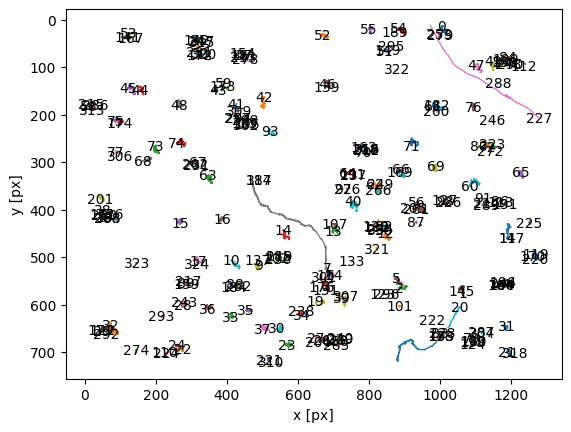

<Axes: xlabel='x [px]', ylabel='y [px]'>

In [53]:
# plots trajectories with labels in original orientation
tp.plot_traj(t1, label=True)

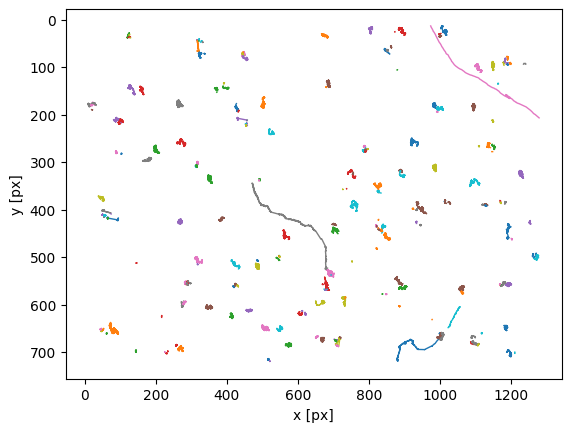

<Axes: xlabel='x [px]', ylabel='y [px]'>

In [57]:
# plots trajectories without labels in original orientation
tp.plot_traj(t1, label=False)

In [58]:
def get_diagonal_size(array):
    lengths = []

    for particle in array:
        lengths.append(tp.diagonal_size(t1[t1["particle"] == particle], pos_columns=None, t_column='frame'))

    lengths = np.array(lengths)
    return lengths

def linear_model(x, A, B):
	y = A + B * x
	return y

# returns best fit power law exponents - 1 is linear = brownian motion
def fit_powerlaw(x, y):
	x = np.log(x)
	y = np.log(y)
	fit, dfit = curve_fit(linear_model, x, y, absolute_sigma = True)
	return fit[1], np.sqrt(dfit[1,1])


# returns numpy array of powers for each particle, with 0 if the power cannot be calculated (not enough frames) and 
# a numpy array of the maximum msd for each particle
def calc_msd(array):
	power = []
	lengths = []
	max_msd = []
	for particle in array:
		a = tp.msd(t1[t1['particle']==particle], upp, fps)
		a = a[a['msd'] != 0] # removes rows of a specific lagtime where parts of calculation includes NaN's or inf's.
		x = a['lagt']
		y = a['msd']
		lengths.append(len(x))
		if len(x) > 10: #and not np.any(y==0):
			c, a = fit_powerlaw(x, y)
			power.append(c)
			max_msd.append(np.max(y))
		else:
			power.append(0)
	power = np.array(power)
	max_msd = np.array(max_msd)
	return power, max_msd


total_diagonal_lengths = get_diagonal_size(arr)
total_msd_powers, total_max_msd = calc_msd(arr)

total = pd.DataFrame({'particle': arr, 'diagonal size': total_diagonal_lengths, 'msd power': total_msd_powers})

In [12]:
# calculates the number of living and dead particles based on diagonal size
def diagonal_size_strat(cutoff):
    numLiving = 0
    numDead = 0
    livinglist  = []
    deadlist = []
    zeros = []

    for index, row in total.iterrows():
        if row['diagonal size'] == 0:
            zeros.append(row['particle'])
        elif row['diagonal size'] < cutoff:
            numDead += 1
            deadlist.append(row['particle'])
        else:
            numLiving += 1
            livinglist.append(row['particle'])

    return numLiving, numDead, livinglist, deadlist

# calculates the number of living and dead particles based on msd power law exponent 
def msd_strat(cutoff):
    numLiving = 0
    numDead = 0
    livinglist  = []
    deadlist = []
    zeros = []

    for index, row in total.iterrows():
        if row['msd power'] == 0:
            zeros.append(row['particle'])
        elif row['msd power'] < cutoff:
            numDead += 1
            deadlist.append(row['particle'])
        else:
            numLiving += 1
            livinglist.append(row['particle'])

    return numLiving, numDead, livinglist, deadlist

In [62]:
numLiving, numDead, livinglist, deadlist = msd_strat(1.1)
print("Diagonal Size:")
print(str(numLiving) + " live bacteria found")
print(str(numDead) + " dead bacteria found")
print("percentage alive: %2.2f %%" % (numLiving * 100 / (numLiving + numDead)))
print("total bacteria: %d" % (numDead + numLiving))

print("\n")

numLiving, numDead, livinglist, deadlist = diagonal_size_strat(60)
print("Diagonal Size:")
print(str(numLiving) + " live bacteria found")
print(str(numDead) + " dead bacteria found")
print("percentage alive: %2.2f %%" % (numLiving * 100 / (numLiving + numDead)))
print("total bacteria: %d" % (numDead + numLiving))

livinglist.append(227)
deadlist = np.array(deadlist)
deadlist = deadlist[deadlist != 227]

Diagonal Size:
41 live bacteria found
173 dead bacteria found
percentage alive: 19.16 %
total bacteria: 214


Diagonal Size:
4 live bacteria found
222 dead bacteria found
percentage alive: 1.77 %
total bacteria: 226


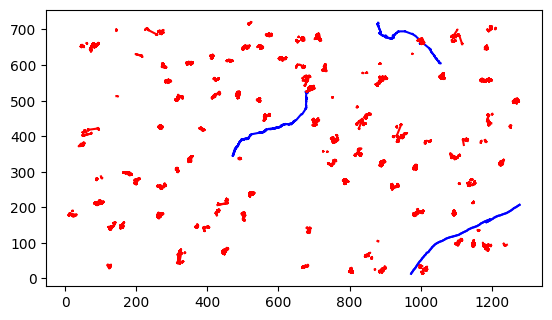

<Figure size 640x480 with 0 Axes>

In [63]:
# plot trajectories for diagonal size classification
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
for i in livinglist:
    plt.plot(t1[t1['particle']==i]['x'], t1[t1['particle']==i]['y'], '-b', label="living")
for i in deadlist:
    plt.plot(t1[t1['particle']==i]['x'], t1[t1['particle']==i]['y'], '-r', label="dead")
#plt.savefig("trajectories.pdf")
plt.show()
plt.clf()

In [ ]:
# split data into living and dead dataframes and save as csv files (can upload for other analysis)
living_df = pd.DataFrame(columns=t1.columns)
living_df.index = pd.MultiIndex.from_tuples([], names=t1.index.names)
living_df = t1.loc[t1['particle'].isin(livinglist)]

dead_df = pd.DataFrame(columns=t1.columns)
dead_df.index = pd.MultiIndex.from_tuples([], names=t1.index.names)
dead_df = t1.loc[t1['particle'].isin(deadlist)]

living_df.to_csv("../trajectory_data/living.csv")
dead_df.to_csv("../trajectory_data/dead.csv")

# ~END OF FILE~